In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from cosmoTransitions import pathDeformation, transitionFinder
from cosmoTransitions import pathDeformation

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar

from AbelianCT_Potential import Abelian_Model as AbelianCT_Model
from AbelianCT_Potential import Abelian_Model

## Define the Model

In [3]:
# Parameters: strong FOPT regime (large g/sqrt(lam) ratio)
lam, mu, g = 0.05, 50.0, 1

model = AbelianCT_Model(lam, mu, g)

# Analytic expectations
v_tree  = mu / np.sqrt(lam)
mh_tree = np.sqrt(2.0) * mu
mA_tree = g * v_tree
print(f"Tree-level vev :  v  = {v_tree:.3f} GeV")
print(f"Tree-level Higgs: mh = {mh_tree:.3f} GeV")
print(f"Tree-level gauge: mA = {mA_tree:.3f} GeV")

# Numerical vev from Vtot(T=0)
T_eps = 1e-6  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v_tree)/v_tree * 100:.3f}%")

Tree-level vev :  v  = 223.607 GeV
Tree-level Higgs: mh = 70.711 GeV
Tree-level gauge: mA = 223.607 GeV
Numerical vev (Vtot, T=0): 223.607 GeV
CW shift: 0.000%


## Coleman Weinberg ($T=0$)

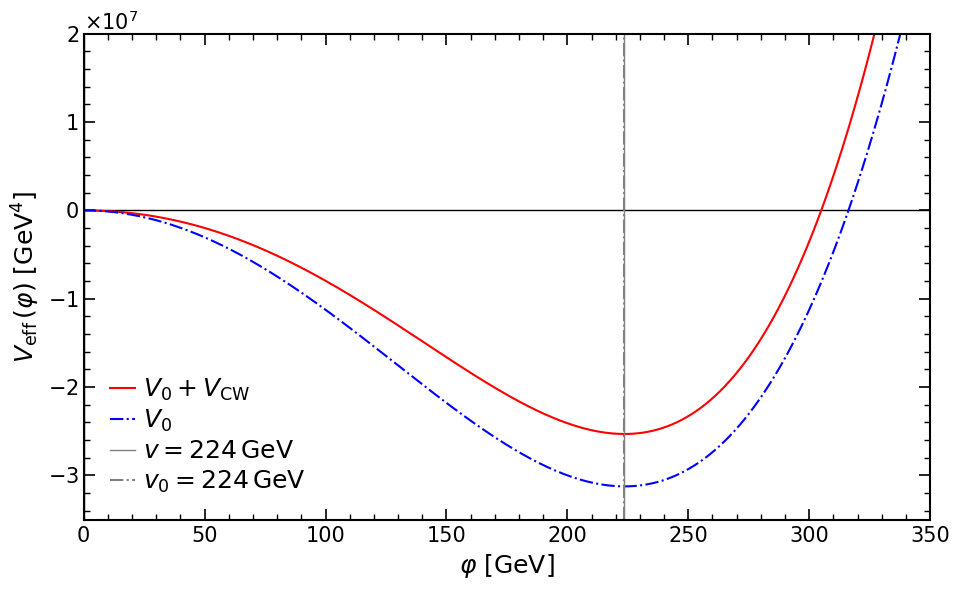

In [35]:
phi_vals = np.linspace(-500, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0-model.Vtot(np.array([[0.0]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree-model.V0(np.array([[0.0]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v_tree, label=rf'$v_0={v_tree:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(0, 350)
ax.set_ylim(-3.5e7,2e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.005, 0.005),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"Coleman-Weinber", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\AbelianCT_CW.png", dpi=1000, bbox_inches="tight")

plt.show()

## Thermal Evolution

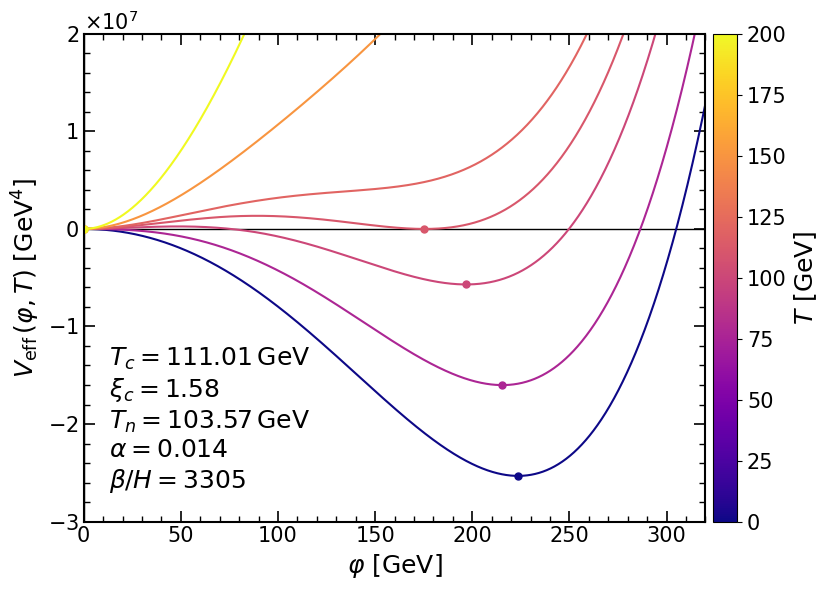

In [31]:
T_vals   = np.array([0, 77, 100, 111, 120, 150, 200])
phi_vals = np.linspace(-1,400,2000)
X        = phi_vals[:, np.newaxis]

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.5, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 0          # Impose Positive vev
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5)

ax.set_xlim(0, 320)
ax.set_ylim(-3e7,2e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi, T)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)


annotation = (rf"$T_c   = 111.01 \, \mathrm{{GeV}}$" 
              "\n"rf"$\xi_c = 1.58$"
              "\n"rf"$T_n = 103.57 \, \mathrm{{GeV}}$" 
              "\n"rf"$\alpha=0.014$"
              "\n"rf"$\beta/H = 3305$")
ax.text(0.04, 0.36, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='left')

#plt.title(r"Thermal Evolution", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\AbelianCT_Thermal.svg", format="svg", bbox_inches="tight")

plt.show()

## Phase Transition

In [5]:
model.findAllTransitions()

Tracing phase starting at x = [223.60679787] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..................................................................................................................................
Tracing phase starting at x = [-3.11523438e-06] ; t = 117.65834360525658
Tracing minimum down
traceMinimum t0 = 117.658
................................
Tracing minimum up
traceMinimum t0 = 117.658
.............
Tracing phase starting at x = [-212.46118257] ; t = 82.71002731086787
Tracing minimum down
traceMinimum t0 = 82.71
........................................
Tracing minimum up
traceMinimum t0 = 82.71
...........................................................................................................


[]

In [7]:
model.Tmax = 200

### Critical Temperature $T_C$

In [21]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.2f}")

Tc = 111.01 GeV  |  xi_c = 1.58


### Nucleation Temperature $T_n$

In [15]:
model.getPhases()
for k, phase in model.phases.items():
    print(f"Phase {k}: T range [{phase.T[0]:.2f}, {phase.T[-1]:.2f}], "
          f"field value at Tmin = {phase.X[0]}")

Tracing phase starting at x = [223.60679787] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..........................................................................................................................................
Tracing phase starting at x = [-3.11523438e-06] ; t = 116.85762646791667
Tracing minimum down
traceMinimum t0 = 116.858
...............................
Tracing minimum up
traceMinimum t0 = 116.858
....
Phase 0: T range [0.00, 116.66], field value at Tmin = [223.60679787]
Phase 1: T range [83.71, 200.00], field value at Tmin = [0.00331977]


In [17]:
from cosmoTransitions import pathDeformation, transitionFinder
import numpy as np

Tc = model.TcTrans[0]['Tcrit']
T_test = 0.999*Tc  # well below Tc, should be clean
# Get the two phase field values at this T
x0 = model.TcTrans[0]['high_vev']   # false vacuum (symmetric)
#x0 = np.array([0.0])   # force it
x1 = model.TcTrans[0]['low_vev']  # true vacuum (broken)

print("False vac:", x0)
print("True vac: ", x1)

# Build the T-fixed potential
V_  = lambda x: model.Vtot(x, T_test)
dV_ = lambda x: model.gradV(x, T_test)

print("V(false):", V_(x0))
print("V(true): ", V_(x1))
print("Delta V: ", V_(x0) - V_(x1))  # must be positive for FOPT

print("=================================")

tobj = pathDeformation.fullTunneling(
    [x1, x0], V_, dV_,
    callback_data=T_test,
    verbose=True
)
print("Action:", tobj.action)
print("S3/T:  ", tobj.action / T_test)

False vac: [-140.18211376]
True vac:  [140.18211372]
V(false): -97417968.60270946
V(true):  -97417968.60268717
Delta V:  -2.2292137145996094e-05
Starting tunneling step 1
Path deformation converged. 1 steps. fRatio = 0.00000e+00
Action: 786.4516383857651
S3/T:   6.7497058769653355


In [15]:
import scipy.optimize as opt

def FindTn(model, T_range, target=140.0):
    x0 = model.TcTrans[0]['high_vev']
    x1 = model.TcTrans[0]['low_vev']

    def f(T):
        # Local potential at this specific temperature step
        V_  = lambda x: model.Vtot(x, T)
        dV_ = lambda x: model.gradV(x, T)
        
        tobj = pathDeformation.fullTunneling([x1, x0], V_, dV_, callback_data=T, verbose=False)
        return (tobj.action / T) - target

    result = opt.root_scalar(f, bracket=T_range, method='brentq', xtol=1e-4)
    
    if result.converged:
        return result.root
    raise ValueError("Root-finding did not converge")

Tc = model.TcTrans[0]['Tcrit']
Tn = FindTn(model, (0.*Tc,0.99*Tc))
print("The nucleation temperature is:", f"{Tn:.4f}", "GeV")
print("Tn/Tc=", f"{Tn/Tc:.6f}")

Path deformation converged. 1 steps. fRatio = 5.69046e-14
Path deformation converged. 1 steps. fRatio = 9.95251e-14
Path deformation converged. 1 steps. fRatio = 5.05224e-14
Path deformation converged. 1 steps. fRatio = 6.39838e-14
Path deformation converged. 1 steps. fRatio = 1.14493e-13
Path deformation converged. 1 steps. fRatio = 5.84989e-14
Path deformation converged. 1 steps. fRatio = 9.65932e-14
Path deformation converged. 1 steps. fRatio = 7.70830e-14
Path deformation converged. 1 steps. fRatio = 7.70876e-14
Path deformation converged. 1 steps. fRatio = 7.70875e-14
Path deformation converged. 1 steps. fRatio = 7.70875e-14
The nucleation temperature is: 103.5721 GeV
Tn/Tc= 0.933008


In [19]:
model.getPhases()
model.calcTcTrans()
Tc = model.TcTrans[0]['Tcrit']
print(f"Tc = {Tc:.4f}")
x0_fixed = np.array([0.0])
def get_broken_vev(T, x_init=None):
    if x_init is None:
        x_init = np.array([246.0])
    V_T = lambda x: model.Vtot(x, T)
    res = minimize(V_T, x_init, method='Nelder-Mead',
                   options={'xatol':1e-8, 'fatol':1e-8})
    return res.x
def compute_S3T(T):
    x1_T = get_broken_vev(T)
    dV = model.Vtot(x0_fixed, T) - model.Vtot(x1_T, T)
    if dV <= 0:
        raise ValueError(f"Phase ordering wrong at T={T:.3f}, dV={dV:.3e}")
    V_  = lambda x: model.Vtot(x, T)
    dV_ = lambda x: model.gradV(x, T)
    tobj = pathDeformation.fullTunneling(
        [x1_T, x0_fixed], V_, dV_, callback_data=T
    )
    return tobj.action / T
# Step 1 — coarse scan to bracket Tn
print("\n--- Coarse scan ---")
T_vals = np.linspace(0.5*Tc, 0.99*Tc, 20)
s3t_vals = []
for T in T_vals:
    try:
        s3t = compute_S3T(T)
    except Exception as e:
        s3t = np.nan
        print(f"T={T:.3f}  FAILED: {e}")
    else:
        print(f"T={T:.3f}  S3/T={s3t:.3f}")
    s3t_vals.append(s3t)
# Step 2 — find bracket where S3/T crosses 140
s3t_arr = np.array(s3t_vals)
# S3/T is large near Tc and small at low T, so we want crossing from below 140 to above
valid = np.isfinite(s3t_arr)
T_valid = T_vals[valid]
s3t_valid = s3t_arr[valid]
# Find index where S3/T crosses 140
cross_idx = np.where(np.diff(np.sign(s3t_valid - 140)))[0]
if len(cross_idx) == 0:
    print("\nNo crossing found — check scan range or nucleation criterion")
else:
    T_lo = T_valid[cross_idx[0]]
    T_hi = T_valid[cross_idx[0] + 1]
    print(f"\nBracket found: [{T_lo:.3f}, {T_hi:.3f}]")
    # Step 3 — refine with brentq
    def objective(T):
        try:
            return compute_S3T(T) - 140.0
        except Exception:
            return np.nan
    Tn = brentq(objective, T_lo, T_hi, xtol=1e-4, maxiter=20)
    print(f"\n*** Nucleation temperature: Tn = {Tn:.4f} GeV ***")
    print(f"    S3/T at Tn = {compute_S3T(Tn):.3f}")
    print(f"    Tc        = {Tc:.4f} GeV")
    print(f"    Tn/Tc     = {Tn/Tc:.4f}")
    print(f"    strength  = v(Tn)/Tn = {get_broken_vev(Tn)[0]/Tn:.4f}")

Tracing phase starting at x = [223.60679787] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..........................................................................................................................................
Tracing phase starting at x = [-3.11523438e-06] ; t = 116.85762646791667
Tracing minimum down
traceMinimum t0 = 116.858
...............................
Tracing minimum up
traceMinimum t0 = 116.858
....
Tc = 111.0088

--- Coarse scan ---
T=55.504  FAILED: The function value at x=1.9266232842027615e+307 is NaN; solver cannot continue.
T=58.367  FAILED: The function value at x=1.948910601224935e+307 is NaN; solver cannot continue.
T=61.230  FAILED: The function value at x=1.9744206178587042e+307 is NaN; solver cannot continue.
T=64.093  FAILED: The function value at x=2.0035894888557707e+307 is NaN; solver cannot continue.
T=66.956  FAILED: The function value at x=2.0369502754139305e+307 is NaN; solver cannot continue.
T=69.819  FAILED: The function value at x

C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337

T=72.682  FAILED: ('V(phi_metaMin) <= V(phi_absMin); tunneling cannot occur.', 'stable, not metastable')
T=75.544  FAILED: ('V(phi_metaMin) <= V(phi_absMin); tunneling cannot occur.', 'stable, not metastable')
T=78.407  FAILED: ('V(phi_metaMin) <= V(phi_absMin); tunneling cannot occur.', 'stable, not metastable')
T=81.270  FAILED: ('V(phi_metaMin) <= V(phi_absMin); tunneling cannot occur.', 'stable, not metastable')
Path deformation converged. 1 steps. fRatio = 7.65947e-14
T=84.133  S3/T=0.428
Path deformation converged. 1 steps. fRatio = 8.46309e-14
T=86.996  S3/T=4.554
Path deformation converged. 1 steps. fRatio = 7.20431e-14
T=89.859  S3/T=11.238
Path deformation converged. 1 steps. fRatio = 3.39489e-14
T=92.722  S3/T=20.697
Path deformation converged. 1 steps. fRatio = 7.98212e-14
T=95.584  S3/T=34.222
Path deformation converged. 1 steps. fRatio = 6.75662e-14
T=98.447  S3/T=54.308
Path deformation converged. 1 steps. fRatio = 6.05653e-14
T=101.310  S3/T=88.517
Path deformation conv

### GW observables: $\alpha$, $\beta$

In [18]:
from scipy.misc import derivative

# --- Parameters ---
g_star = 106.75  # SM dof at the EW scale

# --- Potentials at Tn ---
x1_Tn = get_broken_vev(Tn)
x0_Tn = x0_fixed

V_true  = model.Vtot(x1_Tn, Tn)
V_false = model.Vtot(x0_Tn, Tn)
DeltaV  = V_false - V_true   # > 0

# dDeltaV/dT numerically
def DeltaV_of_T(T):
    x1 = get_broken_vev(T)
    return model.Vtot(x0_fixed, T) - model.Vtot(x1, T)

dDeltaV_dT = derivative(DeltaV_of_T, Tn, dx=0.5)

# Latent heat
Delta_rho = DeltaV - Tn * dDeltaV_dT

# Radiation energy density
rho_rad = (np.pi**2 / 30) * g_star * Tn**4

# Transition strength
alpha = Delta_rho / rho_rad
print(f"ΔV        = {DeltaV:.4e}")
print(f"T dΔV/dT  = {Tn * dDeltaV_dT:.4e}")
print(f"Δρ        = {Delta_rho:.4e}")
print(f"α         = {alpha:.6f}")

# --- β/H ---
def S3T_of_T(T):
    return compute_S3T(T)

dS3T_dT = derivative(S3T_of_T, Tn, dx=0.5)
beta_over_H = Tn * dS3T_dT
print(f"\ndS3T/dT   = {dS3T_dT:.4f}")
print(f"β/H       = {beta_over_H:.4f}")

# --- Summary ---
print(f"\n========= EWPT Observables =========")
print(f"Tc        = {Tc:.4f}  GeV")
print(f"Tn        = {Tn:.4f}  GeV")
print(f"Tn/Tc     = {Tn/Tc:.4f}")
print(f"v(Tn)/Tn  = {x1_Tn[0]/Tn:.4f}")
print(f"α         = {alpha:.6f}")
print(f"β/H       = {beta_over_H:.4f}")
print(f"====================================")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12520\1013898619.py:19: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  dDeltaV_dT = derivative(DeltaV_of_T, Tn, dx=0.5)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12520\1013898619.py:38: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  dS3T_dT = derivative(S3T_of_T, Tn, dx=0.5)


ΔV        = 3.8484e+06
T dΔV/dT  = -5.3871e+07
Δρ        = 5.7719e+07
α         = 0.014282
Path deformation converged. 1 steps. fRatio = 3.88044e-14
Path deformation converged. 1 steps. fRatio = 3.85438e-14
Path deformation converged. 1 steps. fRatio = 3.83476e-14

dS3T/dT   = 31.9074
β/H       = 3304.7168

========= EWPT Observables =========
Tc        = 111.0088  GeV
Tn        = 103.5721  GeV
Tn/Tc     = 0.9330
v(Tn)/Tn  = 1.8497
α         = 0.014282
β/H       = 3304.7168
